In [1]:
import os
import shutil
import random

BASE_PATH = "/kaggle/input/food-101-dataset/data"   # sửa tên cho đúng
OUTPUT_PATH = "/kaggle/working/data"   # nơi tạo dataset mới

TRAIN_SRC = os.path.join(BASE_PATH, "train")
TEST_SRC = os.path.join(BASE_PATH, "test")

TRAIN_DST = os.path.join(OUTPUT_PATH, "training")
VAL_DST = os.path.join(OUTPUT_PATH, "validation")
TEST_DST = os.path.join(OUTPUT_PATH, "evaluation")

# tạo thư mục đích
for path in [TRAIN_DST, VAL_DST, TEST_DST]:
    os.makedirs(path, exist_ok=True)

# 1️⃣ copy test -> evaluation (giữ nguyên)
print("Copying test → evaluation...")
for cls in os.listdir(TEST_SRC):
    src_class = os.path.join(TEST_SRC, cls)
    dst_class = os.path.join(TEST_DST, cls)
    os.makedirs(dst_class, exist_ok=True)

    files = os.listdir(src_class)
    for f in files:
        shutil.copy(os.path.join(src_class, f), os.path.join(dst_class, f))

print("✓ Test copied to evaluation.")

# 2️⃣ chia train -> training + validation
print("Splitting train dataset...")

for cls in os.listdir(TRAIN_SRC):
    src_class = os.path.join(TRAIN_SRC, cls)
    train_class_dst = os.path.join(TRAIN_DST, cls)
    val_class_dst = os.path.join(VAL_DST, cls)

    os.makedirs(train_class_dst, exist_ok=True)
    os.makedirs(val_class_dst, exist_ok=True)

    files = os.listdir(src_class)
    random.shuffle(files)

    total = len(files)
    val_count = int(total * 0.25)   # 25% từ train để được 20% tổng dataset
    val_files = files[:val_count]
    train_files = files[val_count:]

    # copy validation
    for f in val_files:
        shutil.copy(os.path.join(src_class, f), os.path.join(val_class_dst, f))

    # copy training
    for f in train_files:
        shutil.copy(os.path.join(src_class, f), os.path.join(train_class_dst, f))

    print(f"Class {cls}: {len(train_files)} train, {len(val_files)} val")

print("✓ Dataset split completed!")

print("\n🎉 FINAL STRUCTURE:")
print("training   = 60%")
print("validation = 20%")
print("evaluation    = 20%")
print(f"\nOutput path: {OUTPUT_PATH}")

Copying test → evaluation...
✓ Test copied to evaluation.
Splitting train dataset...
Class macarons: 600 train, 200 val
Class french_toast: 600 train, 200 val
Class lobster_bisque: 600 train, 200 val
Class prime_rib: 600 train, 200 val
Class pork_chop: 600 train, 200 val
Class guacamole: 600 train, 200 val
Class baby_back_ribs: 600 train, 200 val
Class mussels: 600 train, 200 val
Class beef_carpaccio: 600 train, 200 val
Class poutine: 600 train, 200 val
Class hot_and_sour_soup: 600 train, 200 val
Class seaweed_salad: 600 train, 200 val
Class foie_gras: 600 train, 200 val
Class dumplings: 600 train, 200 val
Class peking_duck: 600 train, 200 val
Class takoyaki: 600 train, 200 val
Class bibimbap: 600 train, 200 val
Class falafel: 600 train, 200 val
Class pulled_pork_sandwich: 600 train, 200 val
Class lobster_roll_sandwich: 600 train, 200 val
Class carrot_cake: 600 train, 200 val
Class beet_salad: 600 train, 200 val
Class panna_cotta: 600 train, 200 val
Class donuts: 600 train, 200 val
Cla

# Setup and data loading

In [2]:
# ========================================
# 1.1 Install Required Libraries
# ========================================

!pip install --quiet --no-deps ultralytics opencv-python-headless pillow

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 15.4 MB/s eta 0:00:0000:010:01


In [3]:
# ========================================
# 1.2 Import Libraries
# ========================================
import os
import shutil
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import cv2
from PIL import Image
import json
import yaml
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

# For YOLO
from ultralytics import YOLO

print("✓ All libraries imported successfully!")

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
✓ All libraries imported successfully!


In [4]:
# ========================================
# 1.3 Set Up Paths
# ========================================
# Kaggle dataset paths
FOOD101_PATH = '/kaggle/working/data'

# Working directory
WORK_DIR = '/kaggle/working'
OUTPUT_DIR = os.path.join(WORK_DIR, 'outputs')
MODEL_DIR = os.path.join(WORK_DIR, 'models')
DATA_DIR = os.path.join(WORK_DIR, 'yolo_data')

# Create directories
os.makedirs(OUTPUT_DIR, exist_ok=True)
os.makedirs(MODEL_DIR, exist_ok=True)
os.makedirs(DATA_DIR, exist_ok=True)

print("✓ Directory structure created!")

✓ Directory structure created!


In [5]:
# ========================================
# 1.4 Explore Food101 Dataset
# ========================================
def explore_food101_dataset():
    """Explore the Food101 image dataset structure"""
    
    print("=" * 60)
    print("FOOD101 DATASET EXPLORATION")
    print("=" * 60)
    
    # Food categories
    food_categories = [
        'apple_pie', 'baby_back_ribs', 'baklava', 'beef_carpaccio', 'beef_tartare',
        'beet_salad', 'beignets', 'bibimbap', 'bread_pudding', 'breakfast_burrito',
        'bruschetta', 'caesar_salad', 'cannoli', 'caprese_salad', 'carrot_cake',
        'ceviche', 'cheesecake', 'cheese_plate', 'chicken_curry', 'chicken_quesadilla',
        'chicken_wings', 'chocolate_cake', 'chocolate_mousse', 'churros',
        'clam_chowder', 'club_sandwich', 'crab_cakes', 'creme_brulee', 'croque_madame',
        'cup_cakes', 'deviled_eggs', 'donuts', 'dumplings', 'edamame',
        'eggs_benedict', 'escargots', 'falafel', 'filet_mignon', 'fish_and_chips',
        'foie_gras', 'french_fries', 'french_onion_soup', 'french_toast',
        'fried_calamari', 'fried_rice', 'frozen_yogurt', 'garlic_bread', 'gnocchi',
        'greek_salad', 'grilled_cheese_sandwich', 'grilled_salmon', 'guacamole',
        'gyoza', 'hamburger', 'hot_and_sour_soup', 'hot_dog', 'huevos_rancheros',
        'hummus', 'ice_cream', 'lasagna', 'lobster_bisque', 'lobster_roll_sandwich',
        'macaroni_and_cheese', 'macarons', 'miso_soup', 'mussels', 'nachos', 'omelette',
        'onion_rings', 'oysters', 'pad_thai', 'paella', 'pancakes', 'panna_cotta',
        'peking_duck', 'pho', 'pizza', 'pork_chop', 'poutine', 'prime_rib',
        'pulled_pork_sandwich', 'ramen', 'ravioli', 'red_velvet_cake', 'risotto',
        'samosa', 'sashimi', 'scallops', 'seaweed_salad', 'shrimp_and_grits',
        'spaghetti_bolognese', 'spaghetti_carbonara', 'spring_rolls', 'steak',
        'strawberry_shortcake', 'sushi', 'tacos', 'takoyaki', 'tiramisu',
        'tuna_tartare', 'waffles'
    ]
    print(len(food_categories))
    
    splits = ['training', 'validation', 'evaluation']
    
    dataset_info = {}
    
    for split in splits:
        split_path = os.path.join(FOOD101_PATH, split)
        if not os.path.exists(split_path):
            continue
            
        print(f"\n{split.upper()} SET:")
        print("-" * 40)
        
        split_info = {}
        total_images = 0
        
        for idx, category in enumerate(food_categories):
            category_path = os.path.join(split_path, category)
            if os.path.exists(category_path):
                image_files = [f for f in os.listdir(category_path) 
                             if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
                count = len(image_files)
                split_info[category] = count
                total_images += count
                print(f"  {idx}. {category:20s}: {count:5d} images")
        
        print(f"\n  Total {split} images: {total_images}")
        dataset_info[split] = split_info
    
    return dataset_info, food_categories

dataset_info, food_categories = explore_food101_dataset()

FOOD101 DATASET EXPLORATION
101

TRAINING SET:
----------------------------------------
  0. apple_pie           :   600 images
  1. baby_back_ribs      :   600 images
  2. baklava             :   600 images
  3. beef_carpaccio      :   600 images
  4. beef_tartare        :   600 images
  5. beet_salad          :   600 images
  6. beignets            :   600 images
  7. bibimbap            :   600 images
  8. bread_pudding       :   600 images
  9. breakfast_burrito   :   600 images
  10. bruschetta          :   600 images
  11. caesar_salad        :   600 images
  12. cannoli             :   600 images
  13. caprese_salad       :   600 images
  14. carrot_cake         :   600 images
  15. ceviche             :   600 images
  16. cheesecake          :   600 images
  17. cheese_plate        :   600 images
  18. chicken_curry       :   600 images
  19. chicken_quesadilla  :   600 images
  20. chicken_wings       :   600 images
  21. chocolate_cake      :   600 images
  22. chocolate_mous

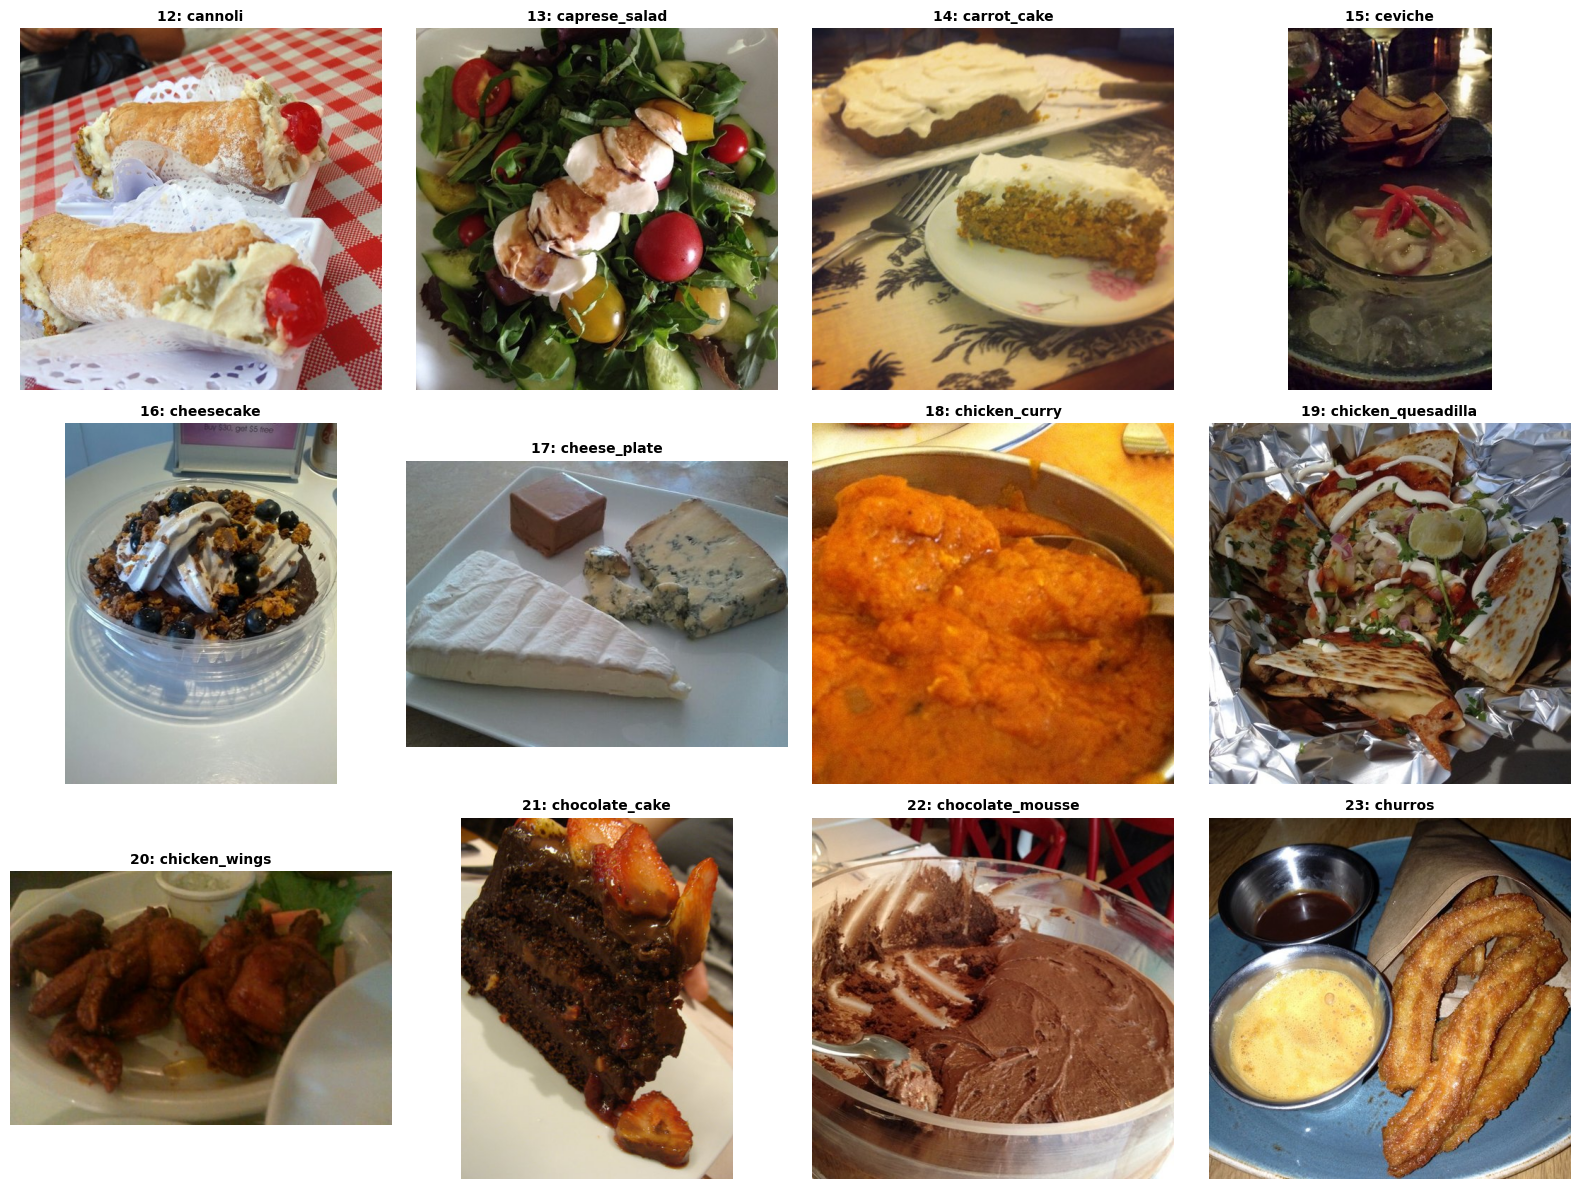

✓ Sample images visualization saved!

STEP 1 COMPLETED SUCCESSFULLY!

Next: Run Step 2 for YOLO data preparation


In [6]:
# ========================================
# 1.7 Display Sample Images
# ========================================
def display_sample_images(num_samples=11):
    """Display sample images from each food category"""
    
    fig, axes = plt.subplots(3, 4, figsize=(16, 12))
    axes = axes.flatten()
    
    training_path = os.path.join(FOOD101_PATH, 'training')
    
    for idx, category in enumerate(food_categories[12:24]):
        category_path = os.path.join(training_path, category)
        if os.path.exists(category_path):
            images = [f for f in os.listdir(category_path) 
                     if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
            if images:
                sample_img_path = os.path.join(category_path, images[0])
                img = Image.open(sample_img_path)
                
                axes[idx].imshow(img)
                axes[idx].set_title(f"{idx+12}: {food_categories[idx+12]}", fontsize=10, fontweight='bold')
                axes[idx].axis('off')
    
    # Hide extra subplot
    axes[11].axis('off')
    
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, 'sample_images.png'), dpi=300, bbox_inches='tight')
    plt.show()
    
    print("✓ Sample images visualization saved!")

display_sample_images()

print("\n" + "=" * 60)
print("STEP 1 COMPLETED SUCCESSFULLY!")
print("=" * 60)
print("\nNext: Run Step 2 for YOLO data preparation")

# YOLO data preparation

In [7]:
import os
import shutil
from pathlib import Path
import yaml
from tqdm import tqdm
import random

In [8]:
# ========================================
# 2.1 YOLO Dataset Structure Setup
# ========================================
def create_yolo_structure():
    """Create YOLO dataset directory structure"""
    
    yolo_root = '/kaggle/working/yolo_dataset'
    
    # Create main directories
    for split in ['train', 'val', 'test']:
        os.makedirs(os.path.join(yolo_root, split, 'images'), exist_ok=True)
        os.makedirs(os.path.join(yolo_root, split, 'labels'), exist_ok=True)
    
    print("✓ YOLO directory structure created!")
    return yolo_root

yolo_root = create_yolo_structure()

✓ YOLO directory structure created!


In [9]:
# ========================================
# 2.2 Convert Food101 to YOLO Format
# ========================================
def convert_food101_to_yolo(food101_path, yolo_root, food_categories):
    """
    Convert Food101 classification dataset to YOLO detection format.
    For single-object images, create bounding box covering most of the image.
    """
    
    print("\n" + "=" * 60)
    print("CONVERTING FOOD101 TO YOLO FORMAT")
    print("=" * 60)
    
    # Mapping: Food101 split -> YOLO split
    split_mapping = {
        'training': 'train',
        'validation': 'val',
        'evaluation': 'test'
    }
    
    stats = {'train': 0, 'val': 0, 'test': 0}
    
    for food101_split, yolo_split in split_mapping.items():
        split_path = os.path.join(food101_path, food101_split)
        
        if not os.path.exists(split_path):
            print(f"⚠ {food101_split} not found, skipping...")
            continue
        
        print(f"\nProcessing {food101_split} -> {yolo_split}...")
        
        for class_id, category in enumerate(food_categories):
            class_path = os.path.join(split_path, category)
            
            if not os.path.exists(class_path):
                continue
            
            images = [f for f in os.listdir(class_path) 
                     if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
            
            for img_name in tqdm(images, desc=f"Class {class_id} ({food_categories[class_id]})"):
                # Source image path
                src_img = os.path.join(class_path, img_name)
                
                # Destination paths
                base_name = f"{food101_split}_{class_id}_{img_name}"
                dst_img = os.path.join(yolo_root, yolo_split, 'images', base_name)
                dst_label = os.path.join(yolo_root, yolo_split, 'labels', 
                                        base_name.rsplit('.', 1)[0] + '.txt')
                
                # Copy image
                shutil.copy2(src_img, dst_img)
                
                # Create YOLO label file
                # Format: class_id x_center y_center width height (normalized 0-1)
                # For classification, assume object is centered and covers 80% of image
                with open(dst_label, 'w') as f:
                    f.write(f"{class_id} 0.5 0.5 0.8 0.8\n")
                
                stats[yolo_split] += 1
    
    print("\n" + "=" * 60)
    print("CONVERSION SUMMARY:")
    print("=" * 60)
    for split, count in stats.items():
        print(f"  {split:6s}: {count:5d} images")
    
    return stats

conversion_stats = convert_food101_to_yolo(FOOD101_PATH, yolo_root, food_categories)


CONVERTING FOOD101 TO YOLO FORMAT

Processing training -> train...


Class 100 (waffles): 100%|██████████| 600/600 [00:00<00:00, 5557.73it/s]



Processing validation -> val...


Class 100 (waffles): 100%|██████████| 200/200 [00:00<00:00, 5704.52it/s]



Processing evaluation -> test...


Class 100 (waffles): 100%|██████████| 200/200 [00:00<00:00, 5711.51it/s]


CONVERSION SUMMARY:
  train : 60600 images
  val   : 20200 images
  test  : 20200 images


In [10]:
# ========================================
# 2.3 Create YOLO Configuration File
# ========================================
def create_yolo_config(yolo_root, food_categories):
    """Create data.yaml configuration file for YOLO training"""
    
    config = {
        'path': yolo_root,  # Dataset root directory
        'train': 'train/images',  # Train images (relative to 'path')
        'val': 'val/images',      # Val images (relative to 'path')
        'test': 'test/images',    # Test images (relative to 'path')
        
        'nc': 101,  # Number of classes
        'names': food_categories  # Class names
    }
    
    config_path = os.path.join(yolo_root, 'data.yaml')
    
    with open(config_path, 'w') as f:
        yaml.dump(config, f, default_flow_style=False, sort_keys=False)
    
    print("\n✓ YOLO configuration file created!")
    print(f"  Location: {config_path}")
    print(f"\nConfiguration:")
    print(yaml.dump(config, default_flow_style=False, sort_keys=False))
    
    return config_path

config_path = create_yolo_config(yolo_root, food_categories)


✓ YOLO configuration file created!
  Location: /kaggle/working/yolo_dataset/data.yaml

Configuration:
path: /kaggle/working/yolo_dataset
train: train/images
val: val/images
test: test/images
nc: 101
names:
- apple_pie
- baby_back_ribs
- baklava
- beef_carpaccio
- beef_tartare
- beet_salad
- beignets
- bibimbap
- bread_pudding
- breakfast_burrito
- bruschetta
- caesar_salad
- cannoli
- caprese_salad
- carrot_cake
- ceviche
- cheesecake
- cheese_plate
- chicken_curry
- chicken_quesadilla
- chicken_wings
- chocolate_cake
- chocolate_mousse
- churros
- clam_chowder
- club_sandwich
- crab_cakes
- creme_brulee
- croque_madame
- cup_cakes
- deviled_eggs
- donuts
- dumplings
- edamame
- eggs_benedict
- escargots
- falafel
- filet_mignon
- fish_and_chips
- foie_gras
- french_fries
- french_onion_soup
- french_toast
- fried_calamari
- fried_rice
- frozen_yogurt
- garlic_bread
- gnocchi
- greek_salad
- grilled_cheese_sandwich
- grilled_salmon
- guacamole
- gyoza
- hamburger
- hot_and_sour_soup
-

In [11]:
# ========================================
# 2.4 Verify Dataset
# ========================================
def verify_yolo_dataset(yolo_root):
    """Verify YOLO dataset structure and files"""
    
    print("\n" + "=" * 60)
    print("VERIFYING YOLO DATASET")
    print("=" * 60)
    
    for split in ['train', 'val', 'test']:
        img_dir = os.path.join(yolo_root, split, 'images')
        label_dir = os.path.join(yolo_root, split, 'labels')
        
        img_count = len([f for f in os.listdir(img_dir) if f.endswith(('.jpg', '.jpeg', '.png'))])
        label_count = len([f for f in os.listdir(label_dir) if f.endswith('.txt')])
        
        print(f"\n{split.upper()} SET:")
        print(f"  Images: {img_count}")
        print(f"  Labels: {label_count}")
        print(f"  Match: {'✓' if img_count == label_count else '✗ MISMATCH!'}")
        
        # Sample verification
        if img_count > 0:
            sample_img = random.choice(os.listdir(img_dir))
            sample_label = sample_img.rsplit('.', 1)[0] + '.txt'
            label_path = os.path.join(label_dir, sample_label)
            
            if os.path.exists(label_path):
                with open(label_path, 'r') as f:
                    label_content = f.read().strip()
                print(f"  Sample label: {label_content}")

verify_yolo_dataset(yolo_root)


VERIFYING YOLO DATASET

TRAIN SET:
  Images: 60600
  Labels: 60600
  Match: ✓
  Sample label: 21 0.5 0.5 0.8 0.8

VAL SET:
  Images: 20200
  Labels: 20200
  Match: ✓
  Sample label: 9 0.5 0.5 0.8 0.8

TEST SET:
  Images: 20200
  Labels: 20200
  Match: ✓
  Sample label: 61 0.5 0.5 0.8 0.8


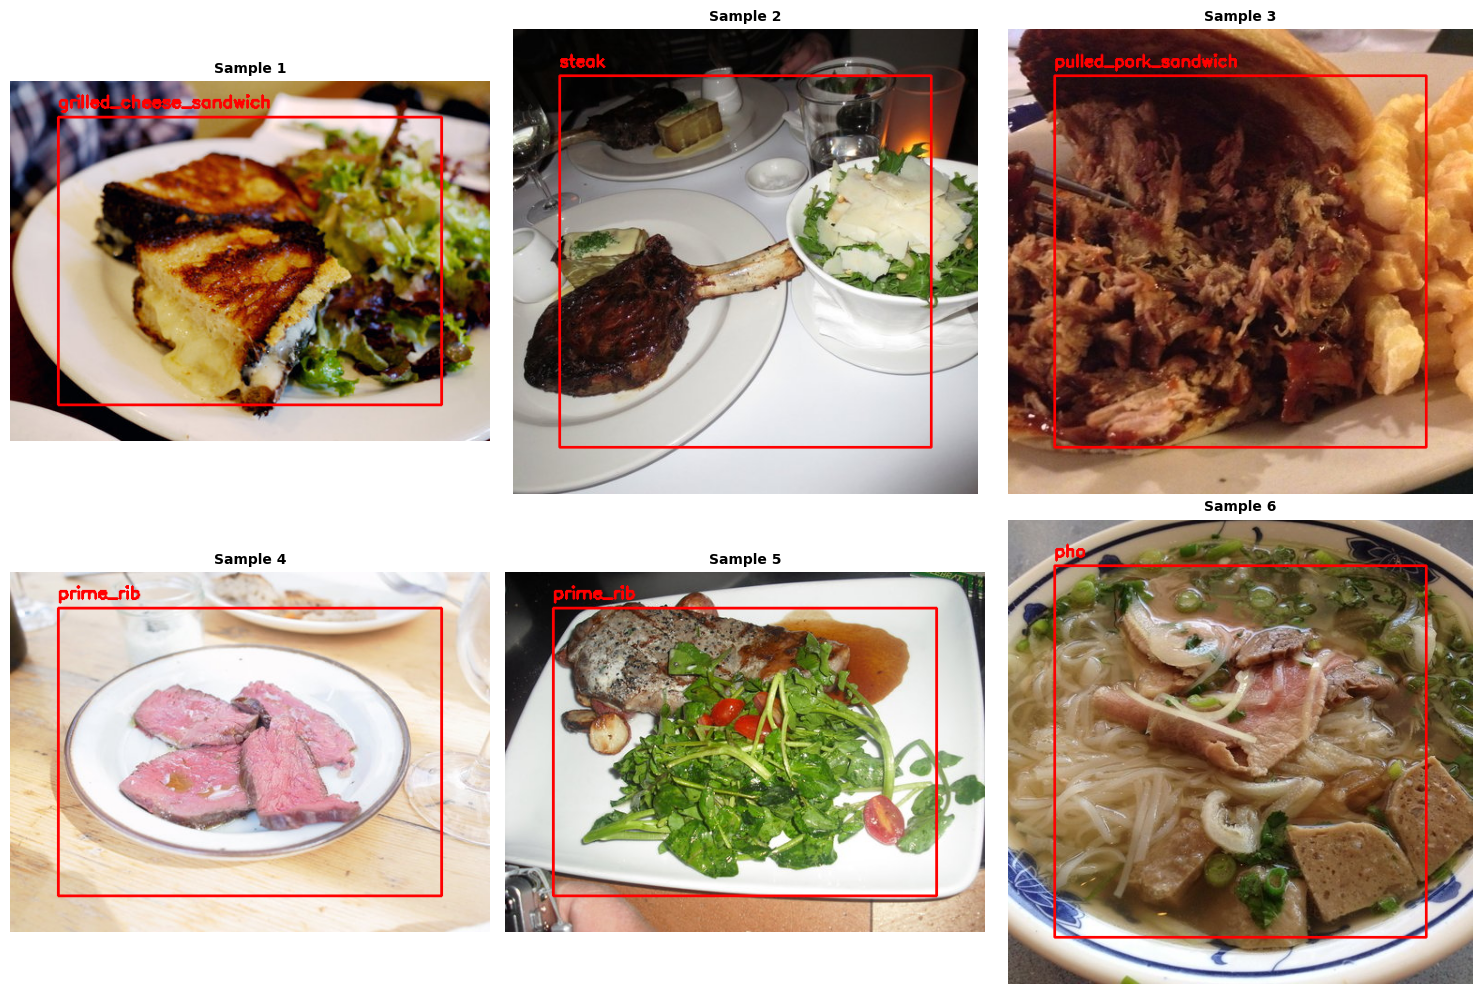

✓ YOLO samples visualization saved!

STEP 2 COMPLETED SUCCESSFULLY!

✓ YOLO dataset ready at: /kaggle/working/yolo_dataset
✓ Configuration file: /kaggle/working/yolo_dataset/data.yaml

Next: Run Step 3 for model training


In [12]:
# ========================================
# 2.5 Visualize YOLO Format Samples
# ========================================
def visualize_yolo_samples(yolo_root, food_categories, num_samples=6):
    """Visualize samples with YOLO annotations"""
    
    import cv2
    import matplotlib.pyplot as plt
    
    fig, axes = plt.subplots(2, 3, figsize=(15, 10))
    axes = axes.flatten()
    
    train_img_dir = os.path.join(yolo_root, 'train', 'images')
    train_label_dir = os.path.join(yolo_root, 'train', 'labels')
    
    images = [f for f in os.listdir(train_img_dir) if f.endswith(('.jpg', '.jpeg', '.png'))]
    samples = random.sample(images, min(num_samples, len(images)))
    
    for idx, img_name in enumerate(samples):
        # Read image
        img_path = os.path.join(train_img_dir, img_name)
        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        h, w = img.shape[:2]
        
        # Read label
        label_name = img_name.rsplit('.', 1)[0] + '.txt'
        label_path = os.path.join(train_label_dir, label_name)
        
        if os.path.exists(label_path):
            with open(label_path, 'r') as f:
                for line in f:
                    class_id, x_center, y_center, width, height = map(float, line.strip().split())
                    
                    # Convert normalized coordinates to pixel coordinates
                    x_center *= w
                    y_center *= h
                    box_width = width * w
                    box_height = height * h
                    
                    x1 = int(x_center - box_width / 2)
                    y1 = int(y_center - box_height / 2)
                    x2 = int(x_center + box_width / 2)
                    y2 = int(y_center + box_height / 2)
                    
                    # Draw bounding box
                    cv2.rectangle(img, (x1, y1), (x2, y2), (255, 0, 0), 2)
                    
                    # Add label
                    label_text = food_categories[int(class_id)]
                    cv2.putText(img, label_text, (x1, y1-10), 
                               cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255, 0, 0), 2)
        
        axes[idx].imshow(img)
        axes[idx].set_title(f"Sample {idx+1}", fontsize=10, fontweight='bold')
        axes[idx].axis('off')
    
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, 'yolo_samples.png'), dpi=300, bbox_inches='tight')
    plt.show()
    
    print("✓ YOLO samples visualization saved!")

visualize_yolo_samples(yolo_root, food_categories)

print("\n" + "=" * 60)
print("STEP 2 COMPLETED SUCCESSFULLY!")
print("=" * 60)
print(f"\n✓ YOLO dataset ready at: {yolo_root}")
print(f"✓ Configuration file: {config_path}")
print("\nNext: Run Step 3 for model training")

# YOLO model training

In [13]:
import os
from ultralytics import YOLO
import matplotlib.pyplot as plt
import pandas as pd
from pathlib import Path
import torch

# Paths
yolo_root = '/kaggle/working/yolo_dataset'
config_path = os.path.join(yolo_root, 'data.yaml')
model_dir = '/kaggle/working/models'

device = 'cuda' if torch.cuda.is_available() else 'cpu'

In [ ]:
# ========================================
# 3.1 Train YOLOv8 Model
# ========================================
def train_yolov8(config_path, epochs=50, img_size=640, batch_size=16):
    """
    Train YOLOv8 model for food detection
    
    Parameters:
    - config_path: Path to data.yaml
    - epochs: Number of training epochs
    - img_size: Image size for training
    - batch_size: Batch size (adjust based on GPU memory)
    """
        
    print("\n" + "=" * 60)
    print("TRAINING YOLOv8 MODEL")
    print("=" * 60)
    
    # Load pretrained YOLOv8 nano model (fastest, good for starting)
    # Options: yolov8n.pt (nano), yolov8s.pt (small), yolov8m.pt (medium)
    model = YOLO('yolov8n.pt')
    
    # Train the model
    results = model.train(
        data=config_path,
        epochs=epochs,
        imgsz=img_size,
        batch=batch_size,
        name='yolov8_food101',
        patience=10,  # Early stopping patience
        save=True,
        plots=True,
        device=device,  # Use GPU if available (use 'cpu' for CPU training)
        workers=4,
        project=model_dir,
        optimizer='AdamW',
        lr0=0.001,  # Initial learning rate
        augment=True,  # Use data augmentation
        cache=True,  # Cache images for faster training
    )
    
    print("\n✓ YOLOv8 training completed!")
    
    # Get best model path
    best_model_path = os.path.join(model_dir, 'yolov8_food101', 'weights', 'best.pt')
    print(f"✓ Best model saved at: {best_model_path}")
    
    return model, best_model_path

# Train YOLOv8
print("Starting YOLOv8 training...")
print("Note: Training may take 30-60 minutes depending on your GPU")
yolov8_model, yolov8_best_path = train_yolov8(config_path, epochs=10)

Starting YOLOv8 training...
Note: Training may take 30-60 minutes depending on your GPU

TRAINING YOLOv8 MODEL
Ultralytics 8.3.235 🚀 Python-3.11.13 torch-2.6.0+cu124 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=True, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=True, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/yolo_dataset/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=10, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=yolov8_food101, nbs=6

In [ ]:
# ========================================
# 3.3 Validate Models
# ========================================
def validate_model(model_path, config_path, model_name):
    """Validate trained model on validation set"""
    
    print(f"\n" + "=" * 60)
    print(f"VALIDATING {model_name}")
    print("=" * 60)
    
    model = YOLO(model_path)
    
    # Run validation
    metrics = model.val(data=config_path)
    
    # Print metrics
    print(f"\nValidation Results for {model_name}:")
    print("-" * 40)
    print(f"  mAP50: {metrics.box.map50:.4f}")
    print(f"  mAP50-95: {metrics.box.map:.4f}")
    print(f"  Precision: {metrics.box.mp:.4f}")
    print(f"  Recall: {metrics.box.mr:.4f}")
    
    return metrics

# Validate both models
yolov8_metrics = validate_model(yolov8_best_path, config_path, "YOLOv8")
#yolov5_metrics = validate_model(yolov5_best_path, config_path, "YOLOv5")

In [ ]:
# ========================================
# 3.6 Test Model on Sample Images
# ========================================
def test_on_samples(model_path, yolo_root, food_categories, num_samples=6):
    """Test trained model on sample images"""
    
    print("\n" + "=" * 60)
    print("TESTING MODEL ON SAMPLES")
    print("=" * 60)
    
    model = YOLO(model_path)
    
    # Get test images
    test_img_dir = os.path.join(yolo_root, 'test', 'images')
    test_images = [f for f in os.listdir(test_img_dir) if f.endswith(('.jpg', '.jpeg', '.png'))]
    samples = random.sample(test_images, min(num_samples, len(test_images)))
    
    fig, axes = plt.subplots(2, 3, figsize=(15, 10))
    axes = axes.flatten()
    
    for idx, img_name in enumerate(samples):
        img_path = os.path.join(test_img_dir, img_name)
        
        # Run inference
        results = model(img_path, conf=0.25)
        
        # Plot results
        result_img = results[0].plot()
        result_img = cv2.cvtColor(result_img, cv2.COLOR_BGR2RGB)
        
        axes[idx].imshow(result_img)
        axes[idx].set_title(f"Test Sample {idx+1}", fontsize=10, fontweight='bold')
        axes[idx].axis('off')
    
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, 'test_predictions.png'), dpi=300, bbox_inches='tight')
    plt.show()
    
    print("✓ Test predictions visualization saved!")

# Test best model
#best_model_path = yolov8_best_path if best_model == 'YOLOv8' else yolov5_best_path
best_model_path = yolov8_best_path
test_on_samples(best_model_path, yolo_root, food_categories)

In [ ]:
# ========================================
# 3.7 Save Model Information
# ========================================
#def save_model_info(best_model, yolov8_metrics, yolov5_metrics, food_categories):
def save_model_info(best_model, yolov8_metrics, food_categories):
    """Save model information for later use"""
    
    model_info = {
        'best_model': best_model,
        'yolov8_path': yolov8_best_path,
        #'yolov5_path': yolov5_best_path,
        'food_categories': food_categories,
        'yolov8_metrics': {
            'mAP50': float(yolov8_metrics.box.map50),
            'mAP50-95': float(yolov8_metrics.box.map),
            'precision': float(yolov8_metrics.box.mp),
            'recall': float(yolov8_metrics.box.mr),
        },
        # 'yolov5_metrics': {
        #     'mAP50': float(yolov5_metrics.box.map50),
        #     'mAP50-95': float(yolov5_metrics.box.map),
        #     'precision': float(yolov5_metrics.box.mp),
        #     'recall': float(yolov5_metrics.box.mr),
        # }
    }
    
    import json
    info_path = os.path.join(model_dir, 'model_info.json')
    with open(info_path, 'w') as f:
        json.dump(model_info, f, indent=4)
    
    print(f"\n✓ Model information saved at: {info_path}")
    return model_info

#model_info = save_model_info(best_model, yolov8_metrics, food_categories)
model_info = save_model_info('YOLOv8', yolov8_metrics, food_categories)

print("\n" + "=" * 60)
print("STEP 3 COMPLETED SUCCESSFULLY!")
print("=" * 60)
print(f"\n✓ Best Model: YOLOv8")
print(f"✓ Model saved at: {yolov8_best_path}")